In [1]:
!pip install wandb huggingface_hub -q

In [3]:
from kaggle_secrets import UserSecretsClient
import wandb
from huggingface_hub import login, HfApi

user_secrets = UserSecretsClient()

wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_api_key)

hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)

api = HfApi()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ojasavrathore_25afi13 (ojasavrathore_25afi13-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, create_repo

HF_REPO = "ojasav-rathore/experiment-9-models"

WANDB_PROJECT = "exp9-gans"
EPOCHS        = 5
BATCH_SIZE    = 128
LATENT_DIM    = 100
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["bce", "lsgan", "wgan"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vanilla", "dcgan"]

print(DEVICE)

cuda


### Dataset

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 264kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.4MB/s]

train: 60000  test: 10000


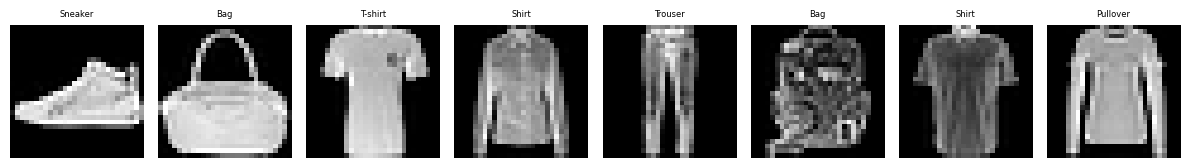

In [5]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train: {len(train_data)}  test: {len(test_data)}')

imgs, labels = next(iter(train_loader))
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Vanilla GAN - Generator and Discriminator

In [6]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(VanillaGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super(VanillaDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

### DCGAN - Generator and Discriminator

In [7]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(DCGenerator, self).__init__()
        self.net = nn.Sequential(
            # latent -> 7x7x256
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 7x7 -> 14x14
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 14x14 -> 28x28
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7 -> 1x1
            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

### Loss Functions - BCE, LSGAN, WGAN

In [8]:
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

def disc_loss(real_out, fake_out, loss_type):
    if loss_type == 'bce':
        real_loss = bce(real_out, torch.ones_like(real_out))
        fake_loss = bce(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'lsgan':
        real_loss = mse(real_out, torch.ones_like(real_out))
        fake_loss = mse(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'wgan':
        return -(real_out.mean() - fake_out.mean())

def gen_loss(fake_out, loss_type):
    if loss_type == 'bce':
        return bce(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'lsgan':
        return mse(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'wgan':
        return -fake_out.mean()

### Optimizer Factory

In [9]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=2e-4, betas=(0.5, 0.999))
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    else:
        return optim.RMSprop(model.parameters(), lr=5e-5)

### Training Loop

In [10]:
def train_epoch(G, D, loader, opt_g, opt_d, loss_type):
    G.train(); D.train()
    g_running = 0
    d_running = 0

    for real, _ in loader:
        real = real.to(DEVICE)
        bs   = real.size(0)

        # train discriminator
        z         = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake      = G(z).detach()
        real_out  = D(real)
        fake_out  = D(fake)
        d_loss    = disc_loss(real_out, fake_out, loss_type)
        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # weight clipping for wgan
        if loss_type == 'wgan':
            for p in D.parameters():
                p.data.clamp_(-0.01, 0.01)

        # train generator
        z        = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake     = G(z)
        fake_out = D(fake)
        g_loss   = gen_loss(fake_out, loss_type)
        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        g_running += g_loss.item()
        d_running += d_loss.item()

    n = len(loader)
    return g_running / n, d_running / n

### Visualization

In [11]:
def show_generated(G, epoch, tag, n=16):
    G.eval()
    with torch.no_grad():
        z    = torch.randn(n, LATENT_DIM).to(DEVICE)
        imgs = G(z).cpu()
    imgs = (imgs + 1) / 2
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'epoch {epoch} - {tag}', fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

### Main Experiment Runner

In [12]:
results       = {}
saved_generators = {}

def run_experiment(arch, loss_type, opt_name):
    name = f'{arch}_{loss_type}_{opt_name}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type, 'optimizer': opt_name, 'epochs': EPOCHS
    })

    if arch == 'vanilla':
        G = VanillaGenerator(LATENT_DIM).to(DEVICE)
        D = VanillaDiscriminator().to(DEVICE)
    else:
        G = DCGenerator(LATENT_DIM).to(DEVICE)
        D = DCDiscriminator().to(DEVICE)

    opt_g = get_optimizer(G, opt_name)
    opt_d = get_optimizer(D, opt_name)

    g_losses = []
    d_losses = []

    for epoch in range(1, EPOCHS + 1):
        g_loss, d_loss = train_epoch(G, D, train_loader, opt_g, opt_d, loss_type)
        g_losses.append(g_loss)
        d_losses.append(d_loss)
        wandb.log({'epoch': epoch, 'g_loss': g_loss, 'd_loss': d_loss})
        print(f'  epoch {epoch}/{EPOCHS}  g_loss={g_loss:.4f}  d_loss={d_loss:.4f}')

        if epoch % 5 == 0 or epoch == EPOCHS:
            fig = show_generated(G, epoch, name)
            wandb.log({f'generated_ep{epoch}': wandb.Image(fig)})
            plt.close(fig)

    # loss curves
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(g_losses, label='generator')
    ax.plot(d_losses, label='discriminator')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(name)
    ax.legend()
    plt.tight_layout()
    plt.show()
    wandb.log({'loss_curve': wandb.Image(fig)})
    plt.close(fig)

    torch.save(G.state_dict(), f'{name}_G.pt')
    torch.save(D.state_dict(), f'{name}_D.pt')
    saved_generators[name] = G
    results[name] = {'g_loss': g_losses[-1], 'd_loss': d_losses[-1]}

    wandb.finish()
    return G, D


starting: vanilla_bce_adam


  epoch 1/5  g_loss=1.1273  d_loss=0.4859
  epoch 2/5  g_loss=1.8823  d_loss=0.4651
  epoch 3/5  g_loss=1.8353  d_loss=0.4717
  epoch 4/5  g_loss=1.6294  d_loss=0.5041
  epoch 5/5  g_loss=1.4199  d_loss=0.5395


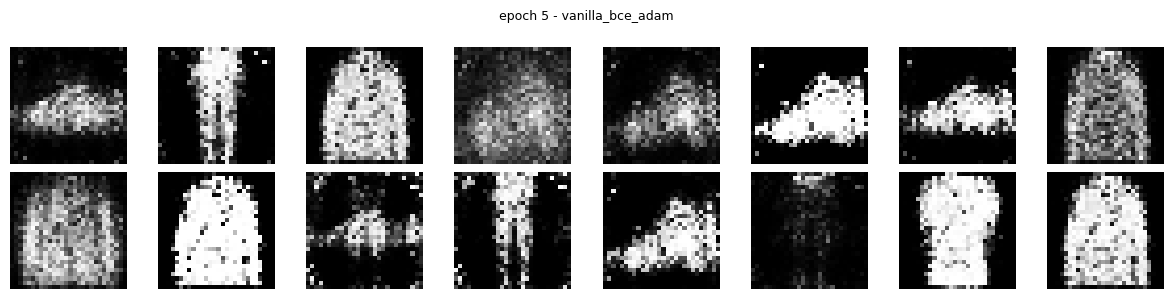

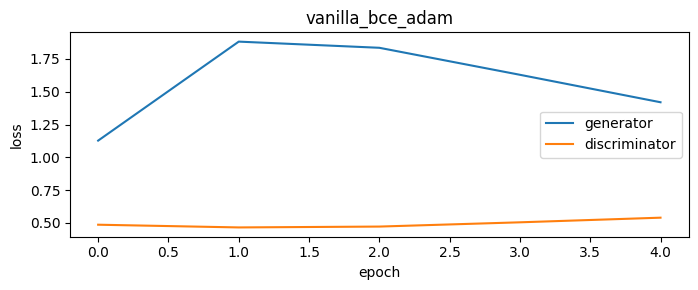

d_loss,▃▁▂▅█
epoch,▁▃▅▆█
g_loss,▁██▆▄
d_loss,0.53952
epoch,5
g_loss,1.41989



starting: dcgan_bce_adam


  epoch 1/5  g_loss=1.3490  d_loss=0.4424
  epoch 2/5  g_loss=1.2496  d_loss=0.4596
  epoch 3/5  g_loss=1.1234  d_loss=0.5114
  epoch 4/5  g_loss=1.1202  d_loss=0.5237
  epoch 5/5  g_loss=1.2780  d_loss=0.4953


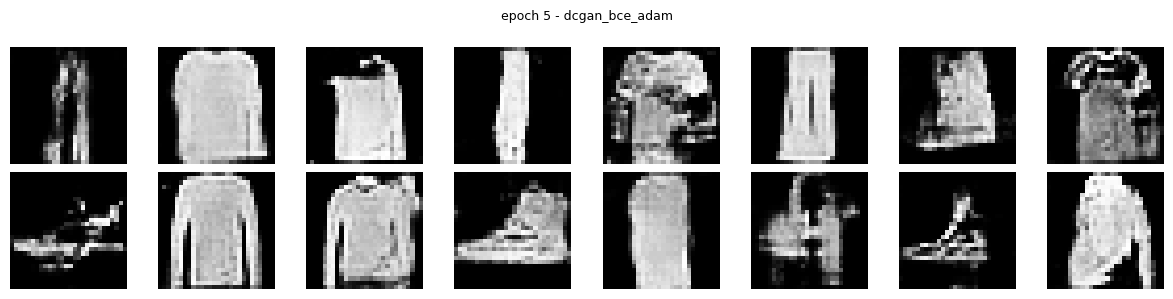

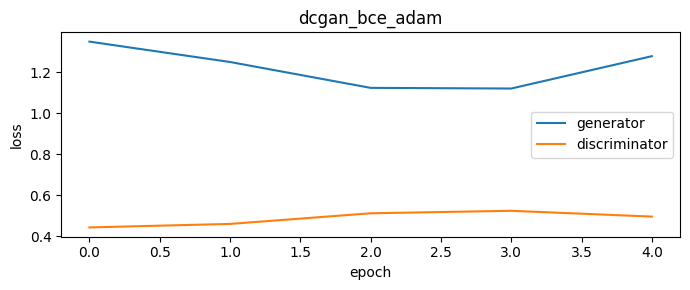

d_loss,▁▂▇█▆
epoch,▁▃▅▆█
g_loss,█▅▁▁▆
d_loss,0.49528
epoch,5
g_loss,1.27802


(DCGenerator(
   (net): Sequential(
     (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
     (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): ReLU(inplace=True)
     (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (7): Tanh()
   )
 ),
 DCDiscriminator(
   (net): Sequential(
     (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (1): LeakyReLU(negative_slope=0.2, inplace=True)
     (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (4): LeakyReLU(negative_slope=0.2, inplace=True)
    

In [13]:
run_experiment('vanilla', 'bce', 'adam')
run_experiment('dcgan',   'bce', 'adam')

### Full Grid - all combinations


starting: vanilla_bce_adam


  epoch 1/5  g_loss=1.2215  d_loss=0.4565
  epoch 2/5  g_loss=1.8512  d_loss=0.4641
  epoch 3/5  g_loss=1.8372  d_loss=0.4903
  epoch 4/5  g_loss=1.6374  d_loss=0.4928
  epoch 5/5  g_loss=1.3835  d_loss=0.5314


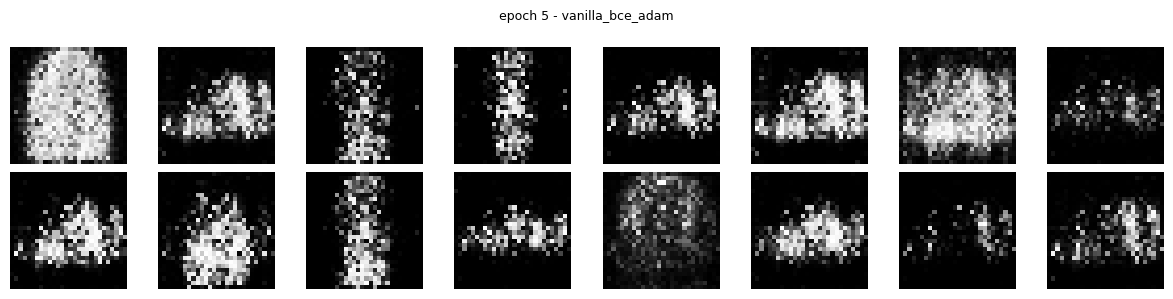

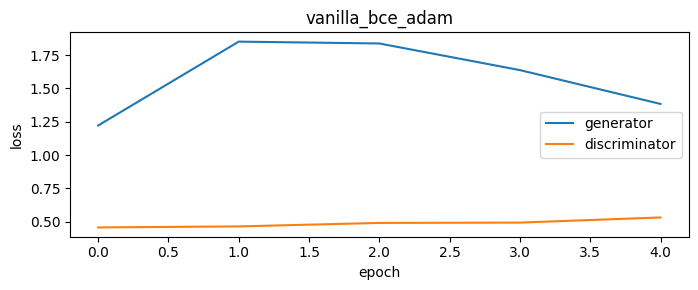

d_loss,▁▂▄▄█
epoch,▁▃▅▆█
g_loss,▁██▆▃
d_loss,0.53139
epoch,5
g_loss,1.38351



starting: vanilla_bce_sgd


  epoch 1/5  g_loss=0.7945  d_loss=0.3779
  epoch 2/5  g_loss=1.5581  d_loss=0.2703
  epoch 3/5  g_loss=2.3817  d_loss=0.1628
  epoch 4/5  g_loss=2.8029  d_loss=0.1369
  epoch 5/5  g_loss=3.0613  d_loss=0.1533


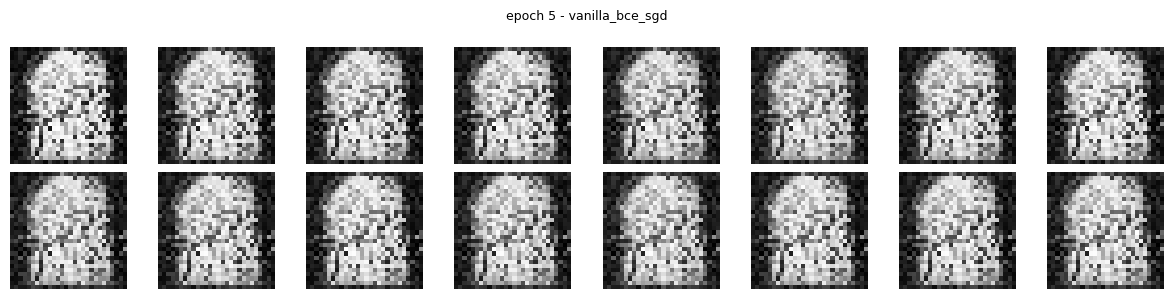

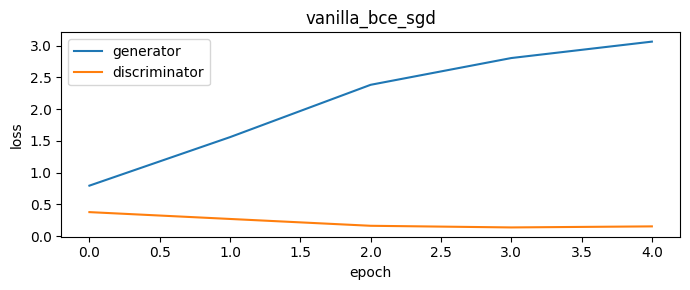

d_loss,█▅▂▁▁
epoch,▁▃▅▆█
g_loss,▁▃▆▇█
d_loss,0.15334
epoch,5
g_loss,3.06134



starting: vanilla_bce_rmsprop


  epoch 1/5  g_loss=0.8561  d_loss=0.4681
  epoch 2/5  g_loss=1.4183  d_loss=0.3557
  epoch 3/5  g_loss=2.1292  d_loss=0.2770
  epoch 4/5  g_loss=2.5750  d_loss=0.2595
  epoch 5/5  g_loss=2.9361  d_loss=0.2276


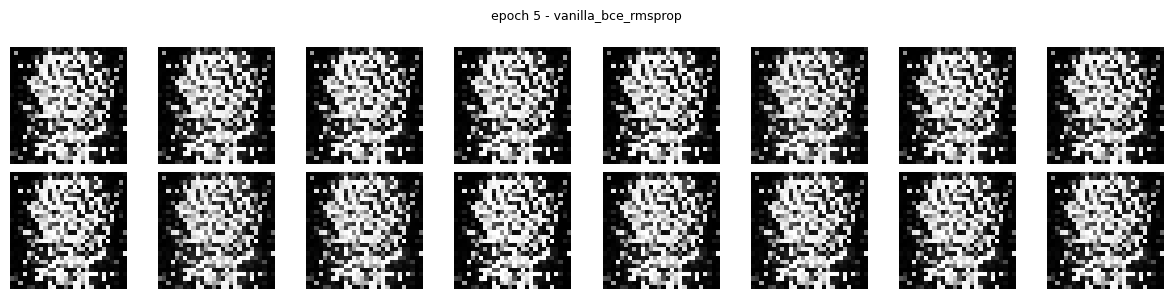

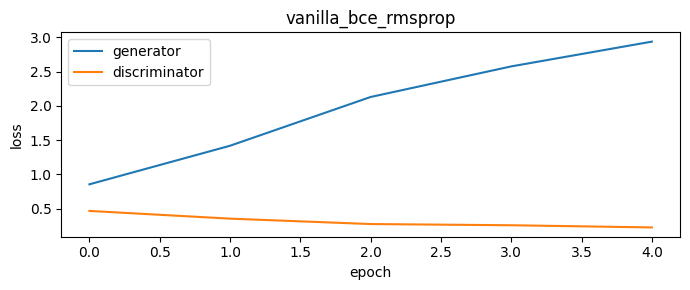

d_loss,█▅▂▂▁
epoch,▁▃▅▆█
g_loss,▁▃▅▇█
d_loss,0.22761
epoch,5
g_loss,2.93608



starting: vanilla_lsgan_adam


  epoch 1/5  g_loss=0.9720  d_loss=0.0795
  epoch 2/5  g_loss=0.7855  d_loss=0.1257
  epoch 3/5  g_loss=0.6838  d_loss=0.1436
  epoch 4/5  g_loss=0.6279  d_loss=0.1541
  epoch 5/5  g_loss=0.5509  d_loss=0.1731


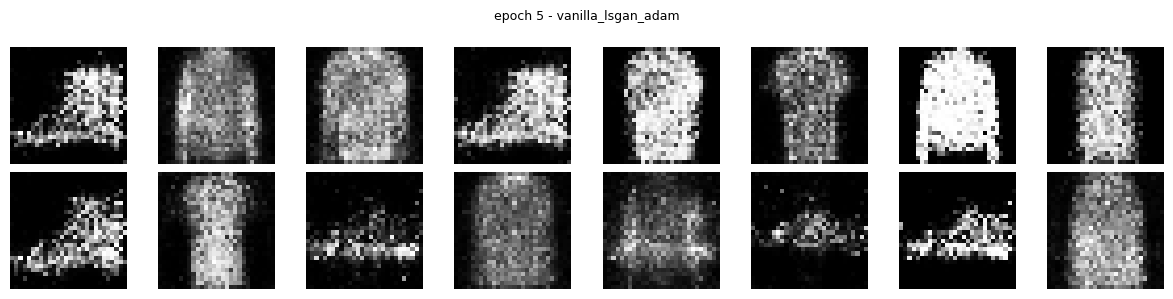

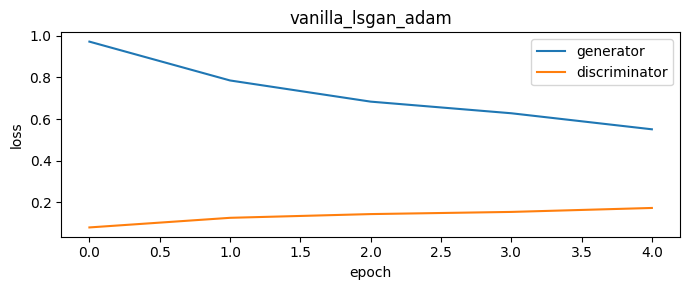

d_loss,▁▄▆▇█
epoch,▁▃▅▆█
g_loss,█▅▃▂▁
d_loss,0.17306
epoch,5
g_loss,0.55091



starting: vanilla_lsgan_sgd


  epoch 1/5  g_loss=0.7041  d_loss=0.0380
  epoch 2/5  g_loss=0.9944  d_loss=0.0362
  epoch 3/5  g_loss=0.9723  d_loss=0.0208
  epoch 4/5  g_loss=0.9672  d_loss=0.0217
  epoch 5/5  g_loss=0.9658  d_loss=0.0202


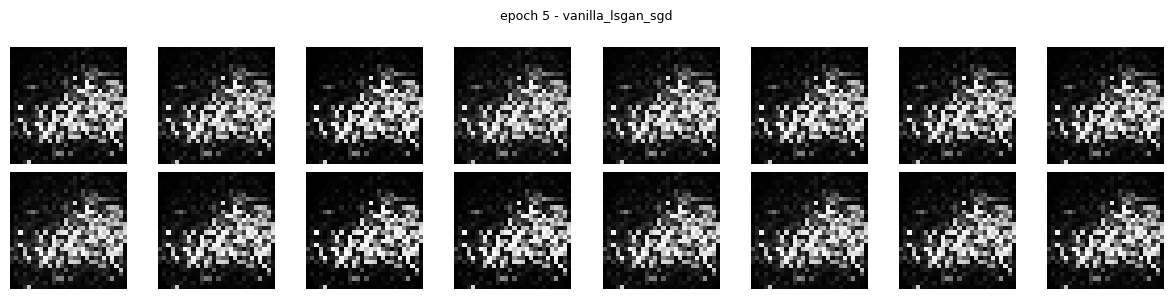

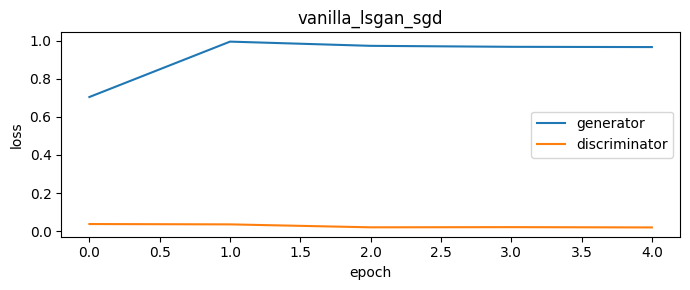

d_loss,█▇▁▂▁
epoch,▁▃▅▆█
g_loss,▁█▇▇▇
d_loss,0.02022
epoch,5
g_loss,0.96581



starting: vanilla_lsgan_rmsprop


  epoch 1/5  g_loss=0.8707  d_loss=0.0679
  epoch 2/5  g_loss=0.9089  d_loss=0.0788
  epoch 3/5  g_loss=0.9113  d_loss=0.0856
  epoch 4/5  g_loss=0.9328  d_loss=0.0817
  epoch 5/5  g_loss=0.9315  d_loss=0.0839


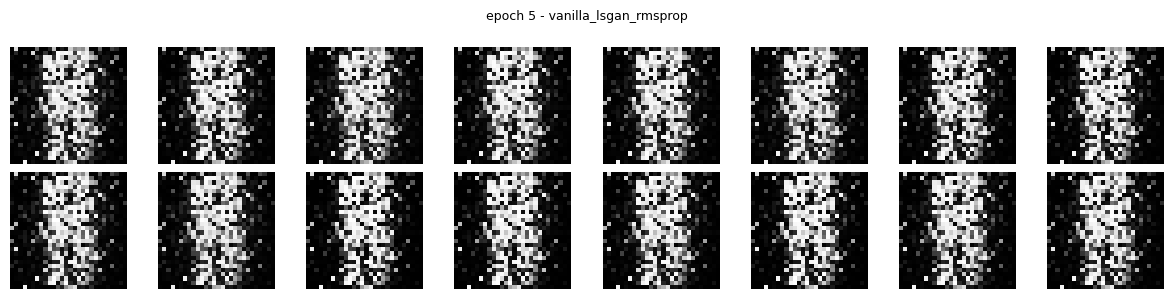

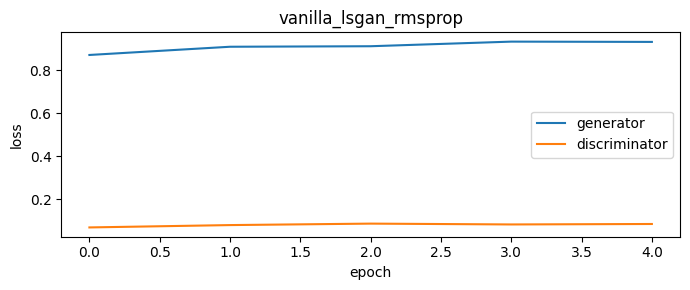

d_loss,▁▅█▆▇
epoch,▁▃▅▆█
g_loss,▁▅▆██
d_loss,0.08388
epoch,5
g_loss,0.93147



starting: vanilla_wgan_adam


  epoch 1/5  g_loss=-0.3340  d_loss=-0.3694
  epoch 2/5  g_loss=-0.0487  d_loss=-0.1970
  epoch 3/5  g_loss=-0.1167  d_loss=-0.4451
  epoch 4/5  g_loss=0.0454  d_loss=-0.2953
  epoch 5/5  g_loss=-0.0007  d_loss=-0.1695


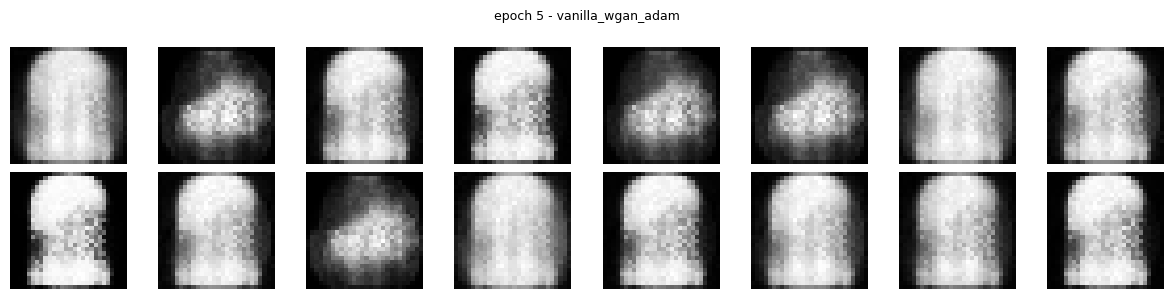

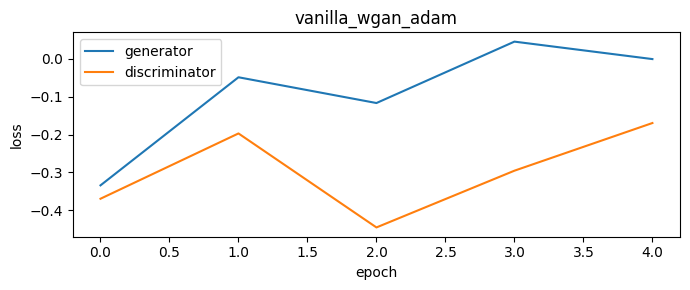

d_loss,▃▇▁▅█
epoch,▁▃▅▆█
g_loss,▁▆▅█▇
d_loss,-0.16951
epoch,5
g_loss,-0.00069



starting: vanilla_wgan_sgd


  epoch 1/5  g_loss=-0.6168  d_loss=-1.6478
  epoch 2/5  g_loss=2.0762  d_loss=-0.4199
  epoch 3/5  g_loss=1.5212  d_loss=-0.5389
  epoch 4/5  g_loss=0.2833  d_loss=-0.6360
  epoch 5/5  g_loss=0.5887  d_loss=-1.9224


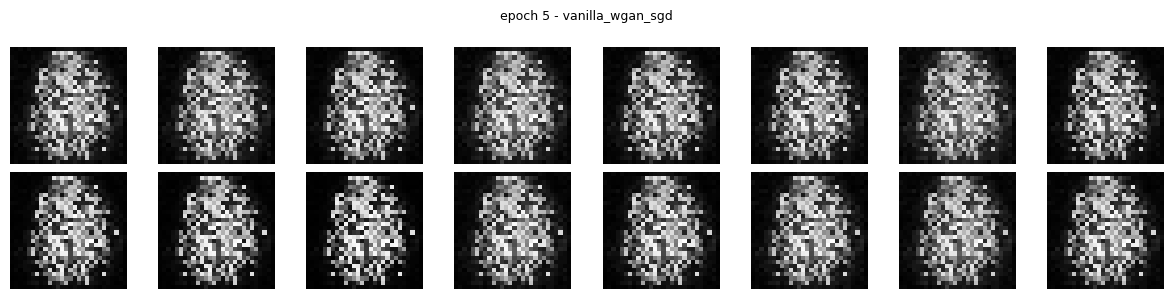

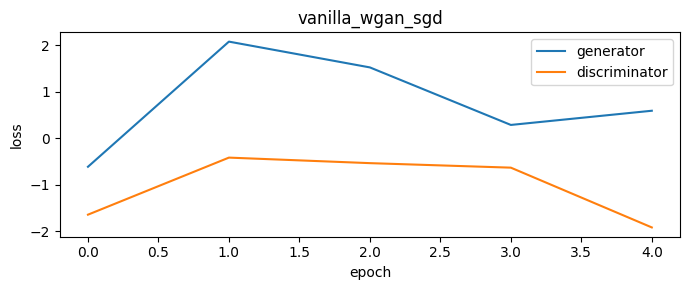

d_loss,▂█▇▇▁
epoch,▁▃▅▆█
g_loss,▁█▇▃▄
d_loss,-1.92238
epoch,5
g_loss,0.5887



starting: vanilla_wgan_rmsprop


  epoch 1/5  g_loss=-0.0937  d_loss=-0.1543
  epoch 2/5  g_loss=0.0003  d_loss=-0.3572
  epoch 3/5  g_loss=-0.2517  d_loss=-0.3157
  epoch 4/5  g_loss=-0.4649  d_loss=-0.3817
  epoch 5/5  g_loss=-0.9214  d_loss=-0.4561


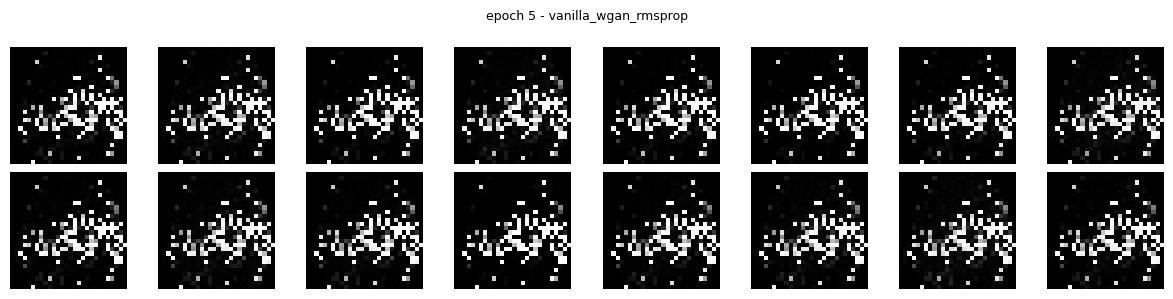

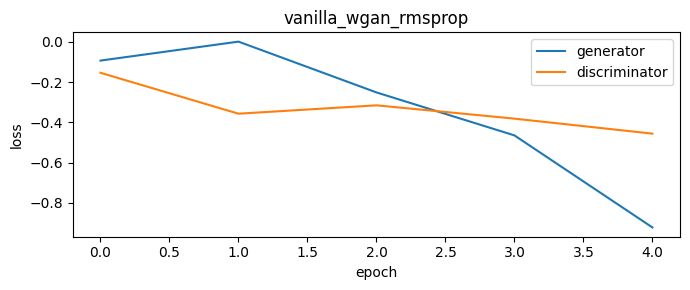

d_loss,█▃▄▃▁
epoch,▁▃▅▆█
g_loss,▇█▆▄▁
d_loss,-0.4561
epoch,5
g_loss,-0.92143



starting: dcgan_bce_adam


  epoch 1/5  g_loss=2.1262  d_loss=0.3026
  epoch 2/5  g_loss=1.5872  d_loss=0.3487
  epoch 3/5  g_loss=1.5154  d_loss=0.3958
  epoch 4/5  g_loss=1.6920  d_loss=0.3836
  epoch 5/5  g_loss=1.3870  d_loss=0.4230


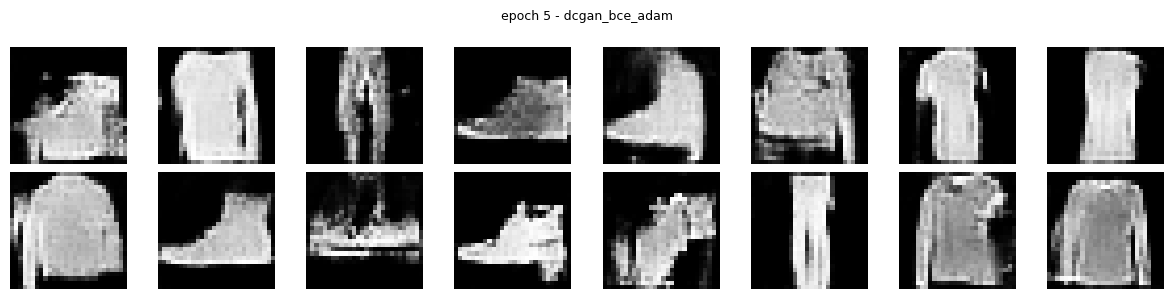

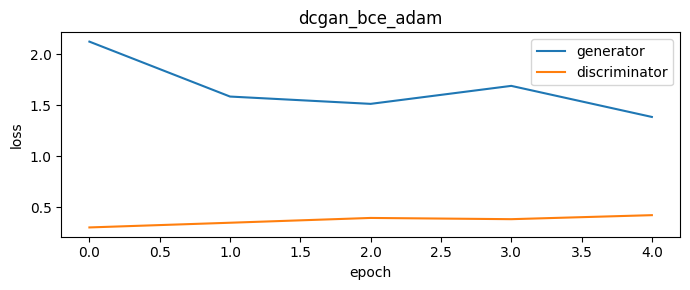

d_loss,▁▄▆▆█
epoch,▁▃▅▆█
g_loss,█▃▂▄▁
d_loss,0.42303
epoch,5
g_loss,1.38696



starting: dcgan_bce_sgd


  epoch 1/5  g_loss=7.2781  d_loss=0.0292
  epoch 2/5  g_loss=7.9298  d_loss=0.0008
  epoch 3/5  g_loss=9.0537  d_loss=0.0003
  epoch 4/5  g_loss=9.5441  d_loss=0.0002
  epoch 5/5  g_loss=9.5567  d_loss=0.0001


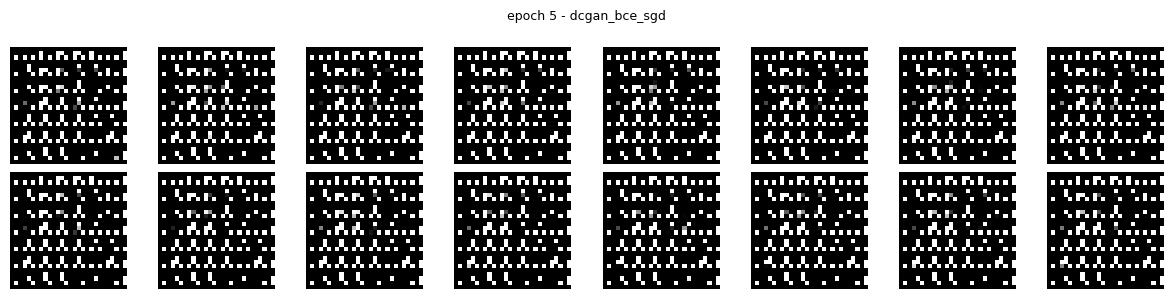

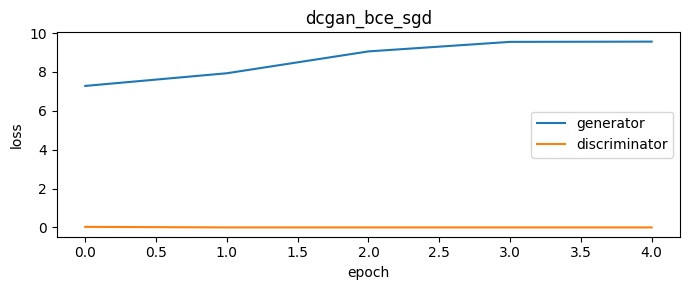

d_loss,█▁▁▁▁
epoch,▁▃▅▆█
g_loss,▁▃▆██
d_loss,0.00014
epoch,5
g_loss,9.55666



starting: dcgan_bce_rmsprop


  epoch 1/5  g_loss=1.7562  d_loss=0.3189
  epoch 2/5  g_loss=1.7531  d_loss=0.2521
  epoch 3/5  g_loss=1.9531  d_loss=0.2217
  epoch 4/5  g_loss=1.7019  d_loss=0.2838
  epoch 5/5  g_loss=1.5786  d_loss=0.3214


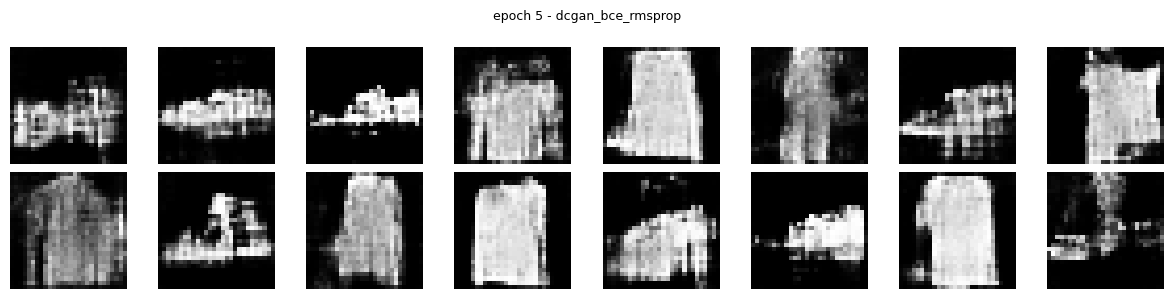

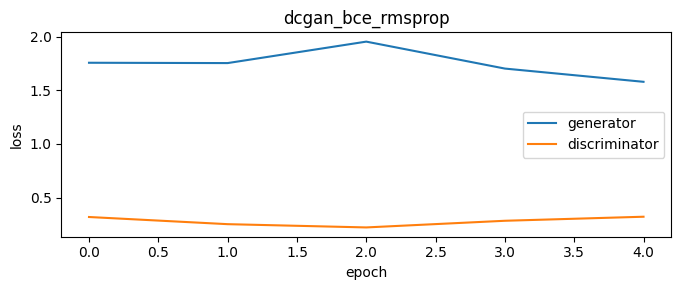

d_loss,█▃▁▅█
epoch,▁▃▅▆█
g_loss,▄▄█▃▁
d_loss,0.32145
epoch,5
g_loss,1.57864



starting: dcgan_lsgan_adam


  epoch 1/5  g_loss=1.0662  d_loss=0.0435
  epoch 2/5  g_loss=1.0405  d_loss=0.0233
  epoch 3/5  g_loss=1.0654  d_loss=0.0321
  epoch 4/5  g_loss=1.1398  d_loss=0.0511
  epoch 5/5  g_loss=1.0390  d_loss=0.0166


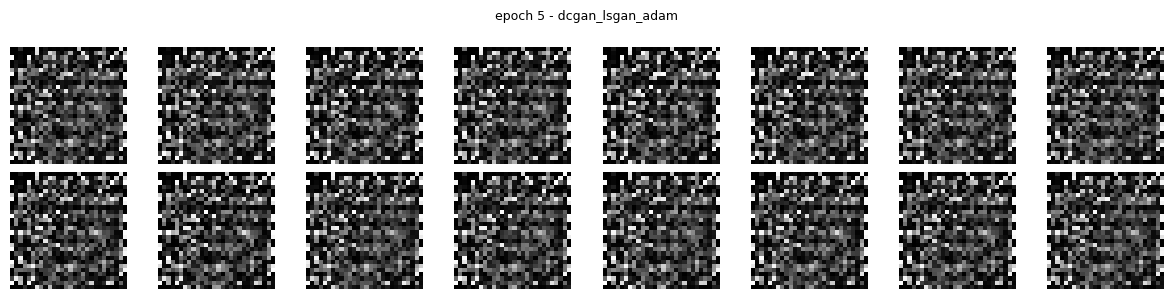

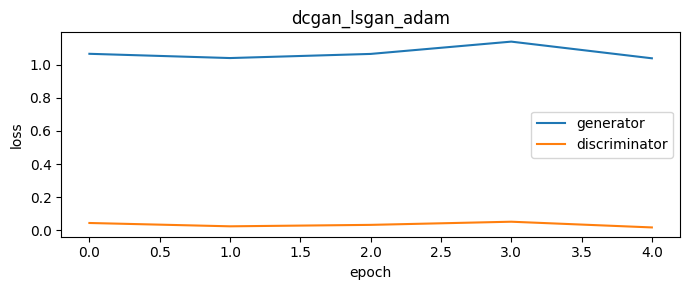

d_loss,▆▂▄█▁
epoch,▁▃▅▆█
g_loss,▃▁▃█▁
d_loss,0.01659
epoch,5
g_loss,1.03899



starting: dcgan_lsgan_sgd


  epoch 1/5  g_loss=1.2462  d_loss=0.1249
  epoch 2/5  g_loss=1.0156  d_loss=0.0044
  epoch 3/5  g_loss=1.0372  d_loss=0.0094
  epoch 4/5  g_loss=1.0122  d_loss=0.0060
  epoch 5/5  g_loss=1.0036  d_loss=0.0029


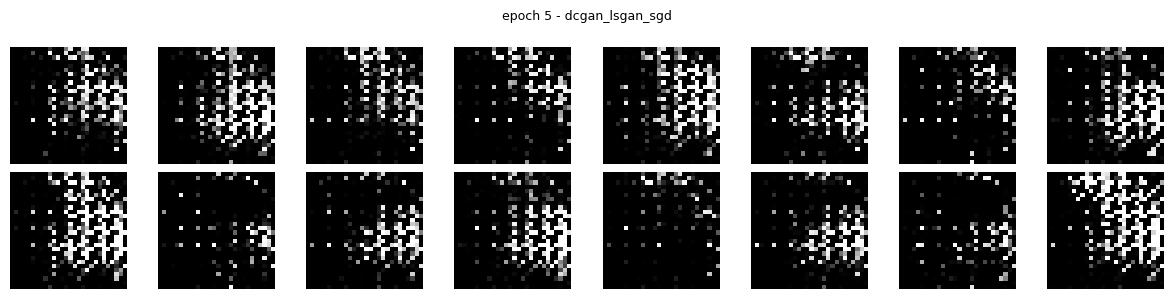

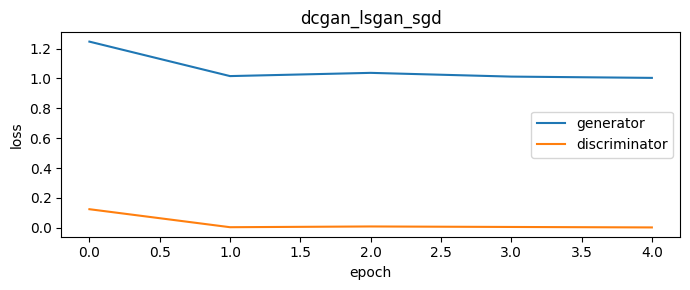

d_loss,█▁▁▁▁
epoch,▁▃▅▆█
g_loss,█▁▂▁▁
d_loss,0.00291
epoch,5
g_loss,1.00362



starting: dcgan_lsgan_rmsprop


  epoch 1/5  g_loss=1.0286  d_loss=0.0394
  epoch 2/5  g_loss=1.0223  d_loss=0.0179
  epoch 3/5  g_loss=1.0232  d_loss=0.0171
  epoch 4/5  g_loss=1.0238  d_loss=0.0155
  epoch 5/5  g_loss=1.0248  d_loss=0.0149


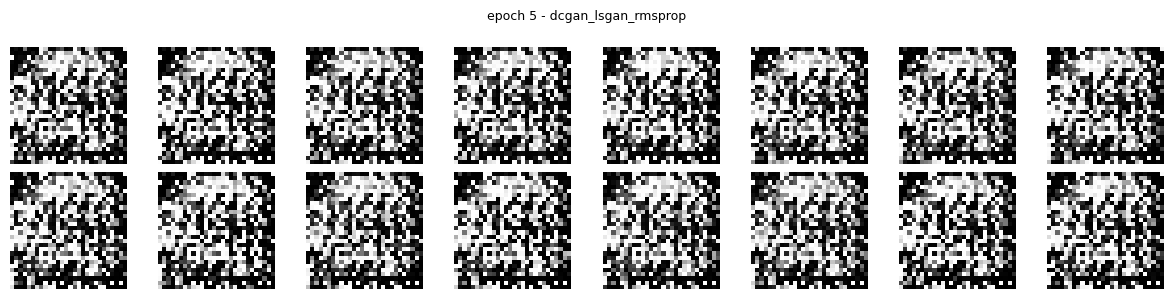

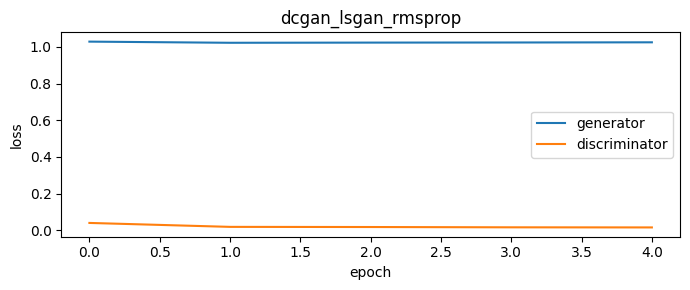

d_loss,█▂▂▁▁
epoch,▁▃▅▆█
g_loss,█▁▂▃▄
d_loss,0.0149
epoch,5
g_loss,1.02482



starting: dcgan_wgan_adam


  epoch 1/5  g_loss=0.0168  d_loss=-0.0213
  epoch 2/5  g_loss=0.0118  d_loss=-0.0063
  epoch 3/5  g_loss=0.0085  d_loss=-0.0098
  epoch 4/5  g_loss=0.0070  d_loss=-0.0078
  epoch 5/5  g_loss=0.0032  d_loss=-0.0054


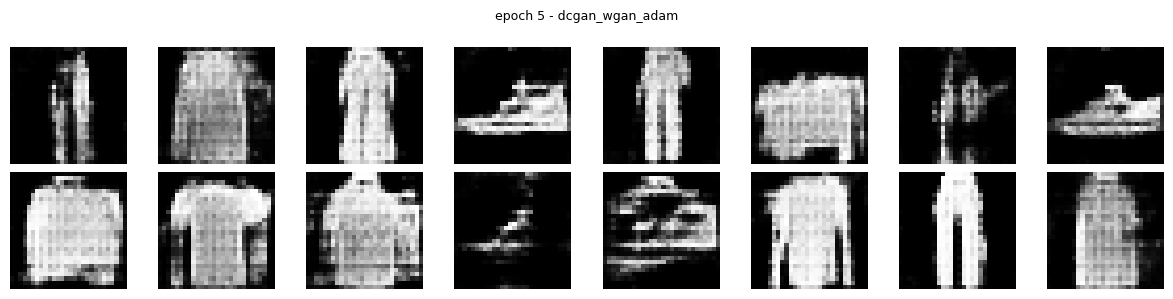

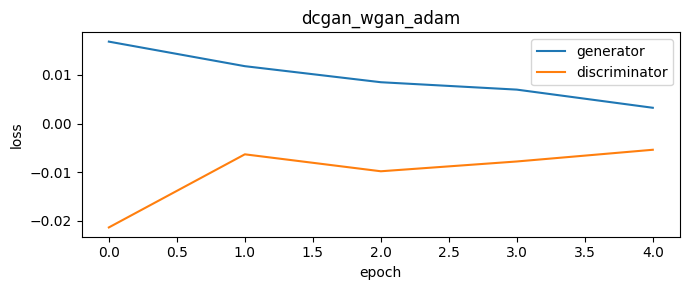

d_loss,▁█▆▇█
epoch,▁▃▅▆█
g_loss,█▅▄▃▁
d_loss,-0.00538
epoch,5
g_loss,0.00325



starting: dcgan_wgan_sgd


  epoch 1/5  g_loss=0.2362  d_loss=-0.4817
  epoch 2/5  g_loss=0.3501  d_loss=-0.7126
  epoch 3/5  g_loss=0.3481  d_loss=-0.7404
  epoch 4/5  g_loss=0.2896  d_loss=-0.6845
  epoch 5/5  g_loss=0.2844  d_loss=-0.6060


In [ ]:
for arch in MODELS:
    for lf in LOSS_FNS:
        for opt in OPTIMIZERS:
            run_experiment(arch, lf, opt)

### Results Summary

In [15]:
print(f'{"config":<35} {"g_loss":>10} {"d_loss":>10}')
print('-' * 57)
for k, v in sorted(results.items(), key=lambda x: x[1]['g_loss']):
    print(f'{k:<35} {v["g_loss"]:>10.4f} {v["d_loss"]:>10.4f}')

config                                  g_loss     d_loss
---------------------------------------------------------
vanilla_wgan_rmsprop                   -0.9214    -0.4561
dcgan_wgan_rmsprop                     -0.0057    -0.0146
vanilla_wgan_adam                      -0.0007    -0.1695
dcgan_wgan_adam                         0.0032    -0.0054
dcgan_wgan_sgd                          0.2844    -0.6060
vanilla_lsgan_adam                      0.5509     0.1731
vanilla_wgan_sgd                        0.5887    -1.9224
vanilla_lsgan_rmsprop                   0.9315     0.0839
vanilla_lsgan_sgd                       0.9658     0.0202
dcgan_lsgan_sgd                         1.0036     0.0029
dcgan_lsgan_rmsprop                     1.0248     0.0149
dcgan_lsgan_adam                        1.0390     0.0166
vanilla_bce_adam                        1.3835     0.5314
dcgan_bce_adam                          1.3870     0.4230
dcgan_bce_rmsprop                       1.5786     0.3214
vanilla_bce_rm

### Upload to HuggingFace

In [16]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_generators.keys():
    for suffix in ['_G.pt', '_D.pt']:
        fname = f'{name}{suffix}'
        if os.path.exists(fname):
            api.upload_file(
                path_or_fileobj=fname,
                path_in_repo=f'models/{fname}',
                repo_id=HF_REPO
            )
            print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

uploaded: vanilla_bce_adam_G.pt


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

uploaded: dcgan_wgan_rmsprop_G.pt


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

uploaded: dcgan_wgan_rmsprop_D.pt
https://huggingface.co/ojasav-rathore/experiment-9-models


In [17]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/ojasavrathore_25afi13-delhi-technological-university/exp9-gans
HF  : https://huggingface.co/ojasav-rathore/experiment-9-models
